# Dynamic Utility Model for Speed Dating Decisions
## Bellman Equation Estimation with Sequential Decision-Making

This notebook is the pedagogical bridge for the climate Dynamic Programming model. It shows Structural Estimation in a simple setting first: an agent observes a sequence of potential partners, compares the current option with the value of waiting, and chooses whether to accept or reject.

The same logic is later used in the climate notebook: instead of accepting a date, the planner chooses an emissions-reduction effort. In both cases, alpha captures the strength of the current payoff channel, and beta captures how much the future matters.


In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('speeddating.csv')

# Clean byte-string columns
byte_cols = ['decision', 'match', 'gender', 'samerace']
for col in byte_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace("b'", '').str.replace("'", '')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Build composite quality score
quality_cols = ['attractive_o', 'intelligence_o', 'funny_o']
quality_cols_present = [c for c in quality_cols if c in df.columns]

if quality_cols_present:
    df['quality'] = df[quality_cols_present].mean(axis=1)
else:
    raise ValueError(f"Missing quality columns. Available: {df.columns.tolist()}")

# Standardize quality
df['quality_std'] = (df['quality'] - df['quality'].mean()) / df['quality'].std()

# Compute date_order and frac_remaining within each wave
if 'wave' in df.columns:
    df['date_order'] = df.groupby('wave').cumcount() + 1
    df['dates_per_wave'] = df.groupby('wave')['wave'].transform('count')
    df['frac_remaining'] = 1 - (df['date_order'] - 1) / df['dates_per_wave']
else:
    df['date_order'] = range(1, len(df) + 1)
    df['dates_per_wave'] = len(df)
    df['frac_remaining'] = 1 - (df['date_order'] - 1) / len(df)

# Remove NaNs
df_clean = df[['decision', 'match', 'quality_std', 'date_order', 'frac_remaining']].dropna()

# Print summary stats
print("=" * 60)
print("DATA SUMMARY STATISTICS")
print("=" * 60)
print(f"Sample size: {len(df_clean)}")
print(f"Yes rate (mean decision): {df_clean['decision'].mean():.4f}")
print(f"Match rate (mean match): {df_clean['match'].mean():.4f}")
print(f"Quality mean: {df_clean['quality_std'].mean():.4f}")
print(f"Quality std dev: {df_clean['quality_std'].std():.4f}")
print(f"Min frac_remaining: {df_clean['frac_remaining'].min():.4f}")
print(f"Max frac_remaining: {df_clean['frac_remaining'].max():.4f}")
print("=" * 60)

DATA SUMMARY STATISTICS
Sample size: 8176
Yes rate (mean decision): 0.4264
Match rate (mean match): 0.1687
Quality mean: -0.0000
Quality std dev: 1.0000
Min frac_remaining: 0.0010
Max frac_remaining: 1.0000


## Exploratory Data Analysis (EDA)

Before building the dynamic model, we explore the data to understand its structure, distributions, and key patterns.

In [2]:
# EDA - 1: Variable distributions and outcome rates
print("=" * 60)
print("EDA: VARIABLE DISTRIBUTIONS")
print("=" * 60)

# Outcome rates
print(f"\nDecision (Yes) rate: {df['decision'].mean():.3f}  ({int(df['decision'].sum())} yes / {len(df)} total)")
if 'match' in df.columns:
    print(f"Match rate:          {df['match'].mean():.3f}  ({int(df['match'].sum())} matches)")

# Quality score distribution
q_cols = ['attractive_o', 'intelligence_o', 'funny_o']
q_present = [c for c in q_cols if c in df.columns]
if q_present:
    print(f"\nQuality sub-scores (mean ± std):")
    for c in q_present:
        print(f"  {c:<20}: {df[c].mean():.2f} ± {df[c].std():.2f}  (missing: {df[c].isna().sum()})")
    print(f"\n  Composite quality : {df['quality'].mean():.2f} ± {df['quality'].std():.2f}")
    print(f"  Standardized      : {df['quality_std'].mean():.4f} ± {df['quality_std'].std():.4f}")

# Wave structure
if 'wave' in df.columns:
    wave_sizes = df.groupby('wave').size()
    print(f"\nWave structure:")
    print(f"  Number of waves   : {df['wave'].nunique()}")
    print(f"  Obs per wave (mean): {wave_sizes.mean():.1f}")
    print(f"  Obs per wave (min/max): {wave_sizes.min()} / {wave_sizes.max()}")

# Gender
if 'gender' in df.columns:
    g = df['gender'].value_counts()
    print(f"\nGender split (0=female, 1=male):")
    for val, cnt in g.items():
        print(f"  {val}: {cnt} ({cnt/len(df)*100:.1f}%)")

# Same-race
if 'samerace' in df.columns:
    sr_rate = df['samerace'].mean()
    print(f"\nSame-race pairs: {sr_rate:.3f} ({int(df['samerace'].sum())} of {len(df)})")

print("=" * 60)

EDA: VARIABLE DISTRIBUTIONS

Decision (Yes) rate: 0.420  (3518 yes / 8378 total)
Match rate:          0.165  (1380 matches)

Quality sub-scores (mean ± std):
  attractive_o        : 6.19 ± 1.95  (missing: 212)
  intelligence_o      : 7.37 ± 1.55  (missing: 306)
  funny_o             : 6.40 ± 1.95  (missing: 360)

  Composite quality : 6.65 ± 1.50
  Standardized      : -0.0000 ± 1.0000

Wave structure:
  Number of waves   : 21
  Obs per wave (mean): 399.0
  Obs per wave (min/max): 50 / 968

Gender split (0=female, 1=male):

Same-race pairs: 0.396 (3316 of 8378)


In [3]:
# EDA - 2: Decision rate by date position and gender
print("=" * 60)
print("EDA: DECISION PATTERNS")
print("=" * 60)

# Yes-rate by date position (t_bin) - requires frac_remaining
if 'frac_remaining' in df.columns:
    T_bins = 10
    df['t_bin_eda'] = pd.cut(df['frac_remaining'], bins=np.linspace(0, 1, T_bins+1),
                              labels=range(T_bins, 0, -1))
    yes_by_pos = df.groupby('t_bin_eda')['decision'].agg(['mean', 'count']).round(3)
    print("\nYes-rate by date position (1=last date, 10=first date):")
    print(f"  {'Date bin':<12} {'Yes rate':<12} {'N':<8}")
    print("  " + "-" * 34)
    for t_bin, row in yes_by_pos.iterrows():
        print(f"  {t_bin:<12} {row['mean']:<12.3f} {int(row['count']):<8}")

# Yes-rate by gender
if 'gender' in df.columns and 'decision' in df.columns:
    print("\nYes-rate by gender (0=female, 1=male):")
    for g_val, g_label in [(0, 'Female'), (1, 'Male')]:
        mask = df['gender'] == g_val
        rate = df.loc[mask, 'decision'].mean()
        n = mask.sum()
        print(f"  {g_label:<8}: {rate:.3f}  (n={n})")

# Yes-rate by same-race
if 'samerace' in df.columns and 'decision' in df.columns:
    print("\nYes-rate by same-race pair:")
    for sr_val, sr_label in [(0, 'Different race'), (1, 'Same race')]:
        mask = df['samerace'] == sr_val
        rate = df.loc[mask, 'decision'].mean()
        n = mask.sum()
        print(f"  {sr_label:<16}: {rate:.3f}  (n={n})")

# Correlations with decision
print("\nTop correlations with decision:")
numeric_df = df.select_dtypes(include=[np.number])
if 'decision' in numeric_df.columns:
    corr = numeric_df.corr()['decision'].drop('decision').sort_values(key=abs, ascending=False)
    for col, val in corr.head(8).items():
        print(f"  {col:<25}: {val:+.3f}")

print("=" * 60)

EDA: DECISION PATTERNS

Yes-rate by date position (1=last date, 10=first date):
  Date bin     Yes rate     N       
  ----------------------------------
  10           0.465        833     
  9            0.449        837     
  8            0.512        838     
  7            0.492        837     
  6            0.454        844     
  5            0.372        833     
  4            0.387        837     
  3            0.345        838     
  2            0.338        837     
  1            0.385        844     

Yes-rate by gender (0=female, 1=male):
  Female  : nan  (n=0)
  Male    : nan  (n=0)

Yes-rate by same-race pair:
  Different race  : 0.411  (n=5062)
  Same race       : 0.434  (n=3316)

Top correlations with decision:
  match                    : +0.522
  like                     : +0.513
  attractive_partner       : +0.487
  funny_partner            : +0.414
  shared_interests_partner : +0.401
  guess_prob_liked         : +0.311
  expected_num_matches     : +0.229
  in

EDA figure saved as 'eda_plots.png'


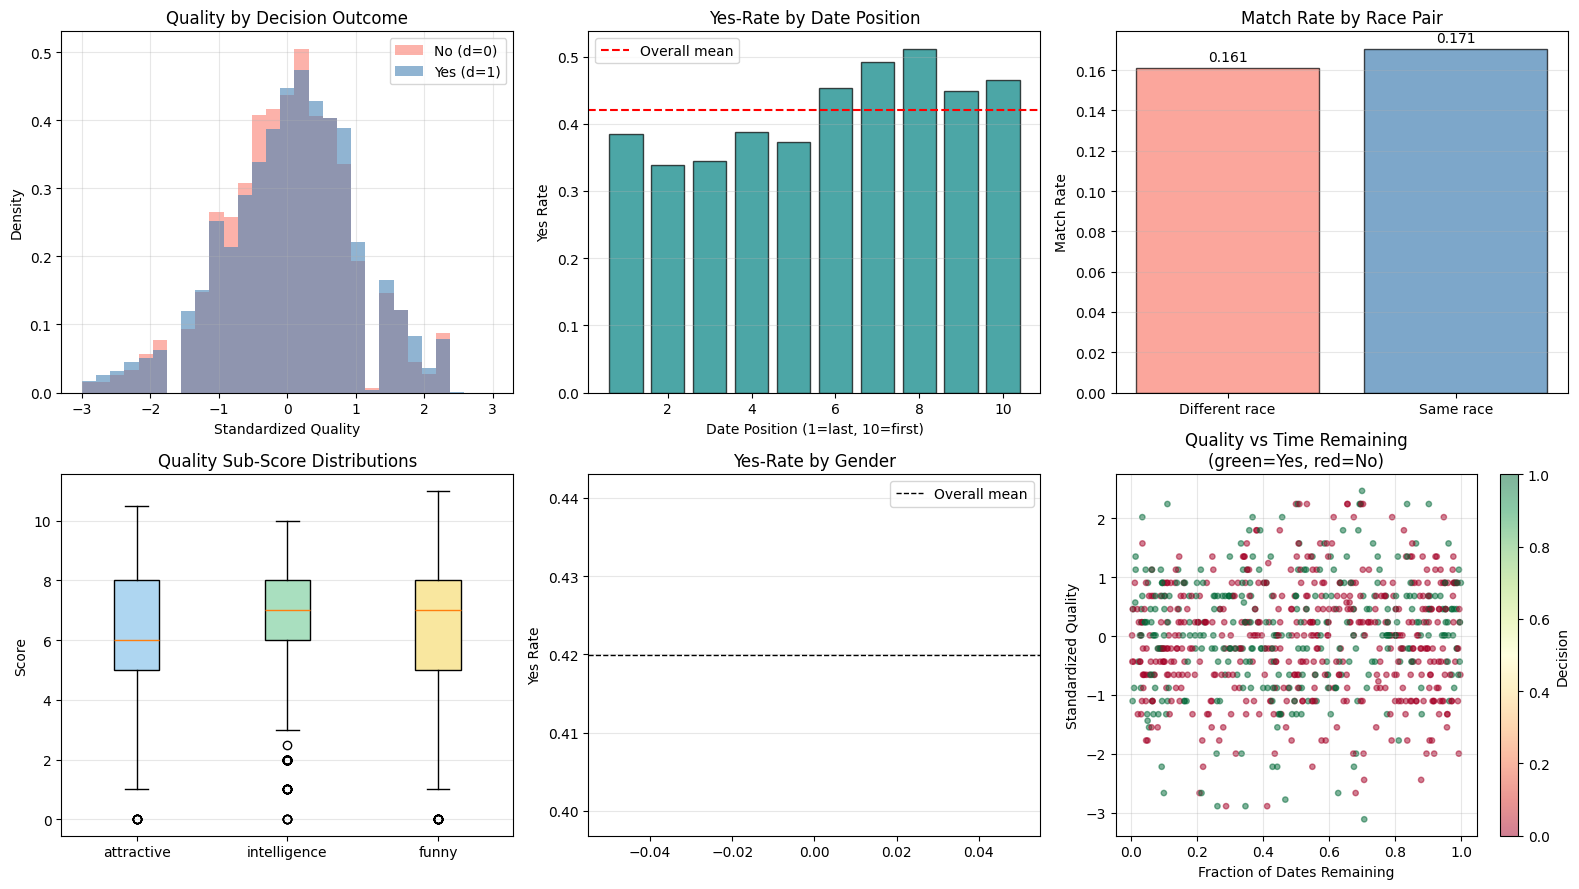

In [4]:
# EDA - 3: Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Panel 1: Quality score histogram by decision
ax = axes[0, 0]
if 'quality_std' in df.columns and 'decision' in df.columns:
    df_yes = df[df['decision'] == 1]['quality_std'].dropna()
    df_no  = df[df['decision'] == 0]['quality_std'].dropna()
    bins = np.linspace(-3, 3, 30)
    ax.hist(df_no,  bins=bins, alpha=0.6, label='No (d=0)',  color='salmon',    density=True)
    ax.hist(df_yes, bins=bins, alpha=0.6, label='Yes (d=1)', color='steelblue', density=True)
    ax.set_xlabel('Standardized Quality')
    ax.set_ylabel('Density')
    ax.set_title('Quality by Decision Outcome')
    ax.legend()
    ax.grid(alpha=0.3)

# Panel 2: Yes-rate by date position
ax = axes[0, 1]
if 't_bin_eda' in df.columns:
    yes_by_pos = df.groupby('t_bin_eda')['decision'].mean()
    ax.bar(yes_by_pos.index.astype(int), yes_by_pos.values, color='teal', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Date Position (1=last, 10=first)')
    ax.set_ylabel('Yes Rate')
    ax.set_title('Yes-Rate by Date Position')
    ax.axhline(df['decision'].mean(), color='red', linestyle='--', label='Overall mean')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Panel 3: Match rate by same-race
ax = axes[0, 2]
if 'samerace' in df.columns and 'match' in df.columns:
    match_by_race = df.groupby('samerace')['match'].mean()
    bars = ax.bar(['Different race', 'Same race'], match_by_race.values,
                  color=['salmon', 'steelblue'], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Match Rate')
    ax.set_title('Match Rate by Race Pair')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, match_by_race.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# Panel 4: Quality sub-score distributions
ax = axes[1, 0]
q_present = [c for c in ['attractive_o', 'intelligence_o', 'funny_o'] if c in df.columns]
if q_present:
    data = [df[c].dropna().values for c in q_present]
    bp = ax.boxplot(data, labels=[c.replace('_o', '') for c in q_present], patch_artist=True)
    colors_bp = ['#AED6F1', '#A9DFBF', '#F9E79F']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
    ax.set_ylabel('Score')
    ax.set_title('Quality Sub-Score Distributions')
    ax.grid(axis='y', alpha=0.3)

# Panel 5: Yes-rate by gender
ax = axes[1, 1]
if 'gender' in df.columns and 'decision' in df.columns:
    yes_by_gender = df.groupby('gender')['decision'].mean()
    labels = {0: 'Female', 1: 'Male'}
    ax.bar([labels.get(g, str(g)) for g in yes_by_gender.index],
           yes_by_gender.values, color=['#F1948A', '#7FB3D3'], alpha=0.8, edgecolor='black')
    ax.set_ylabel('Yes Rate')
    ax.set_title('Yes-Rate by Gender')
    ax.axhline(df['decision'].mean(), color='black', linestyle='--', linewidth=1, label='Overall mean')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Panel 6: Scatter: quality vs frac_remaining colored by decision
ax = axes[1, 2]
if 'quality_std' in df.columns and 'frac_remaining' in df.columns:
    sample = df[['quality_std', 'frac_remaining', 'decision']].dropna().sample(min(800, len(df)), random_state=42)
    sc = ax.scatter(sample['frac_remaining'], sample['quality_std'],
                    c=sample['decision'], cmap='RdYlGn', alpha=0.5, s=15)
    ax.set_xlabel('Fraction of Dates Remaining')
    ax.set_ylabel('Standardized Quality')
    ax.set_title('Quality vs Time Remaining\n(green=Yes, red=No)')
    plt.colorbar(sc, ax=ax, label='Decision')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
print("EDA figure saved as 'eda_plots.png'")
plt.show()

## Dynamic Programming

Dynamic programming (DP) solves multi-stage decision problems by breaking them into simpler sub-problems. The key idea is **Bellman's principle of optimality**: an optimal policy has the property that, regardless of the initial decision, the remaining decisions must form an optimal policy.

### Core Structure
1. **State**: a variable summarizing all relevant information at each stage (e.g., period $t$, current quality draw $x$)
2. **Action**: the decision at each stage (e.g., accept or reject)
3. **Value function** $V(s)$: expected total reward from state $s$ under the optimal policy
4. **Bellman equation**: $V(s) = \max_a \{ r(s,a) + \beta \, \mathbb{E}[V(s')] \}$

### Solving by Backward Induction
For finite-horizon problems, we start at the terminal period (where the value is known) and work **backwards**, computing $V(t, \cdot)$ from $V(t+1, \cdot)$ at each step.

### Classic Examples
- **Optimal stopping** (Secretary Problem): when to stop searching and select the best candidate seen so far
- **Inventory control**: how many units to stock given uncertain demand
- **Job search**: when to accept a wage offer from a known wage distribution

In [5]:
# Basic DP Example 1: Optimal Stopping (Job Search / Secretary Problem)
#
# An agent receives T wage offers drawn i.i.d. from Uniform[0, 1].
# They can accept any offer (and stop), or reject it and move on.
# No recall: once rejected, an offer is gone.
# At the terminal period T, the agent must accept whatever is offered.
#
# Bellman equation:
#   V(t) = E[max(w, V(t+1))]  for t < T
#   V(T) = E[w] = 0.5         (must accept last offer)
#
# Reservation wage w*(t): accept if w >= w*(t), else reject.

print("=" * 60)
print("BASIC DP EXAMPLE: OPTIMAL STOPPING (JOB SEARCH)")
print("=" * 60)

def solve_job_search(T=10, n_grid=200):
    """Backward induction for job search with uniform wage offers."""
    w_grid = np.linspace(0, 1, n_grid)
    dw = w_grid[1] - w_grid[0]

    # Terminal value: must accept, so V(T) = E[w] = 0.5
    V = np.zeros(T + 1)
    V[T] = 0.5

    # Reservation wage: at each t, accept if w >= w*(t)
    w_star = np.zeros(T + 1)

    for t in range(T - 1, 0, -1):
        # E[max(w, V(t+1))] = integral over w of max(w, V(t+1))
        # = integral_{0}^{V(t+1)} V(t+1) dw  +  integral_{V(t+1)}^{1} w dw
        v_next = V[t + 1]
        # V(t) = V(t+1) * V(t+1) + (1 - V(t+1)^2) / 2
        V[t] = v_next * v_next + (1 - v_next**2) / 2
        w_star[t] = v_next  # Accept iff w >= V(t+1)

    w_star[T] = 0.0  # At last period accept anything

    return V, w_star

T_search = 10
V_search, w_star_search = solve_job_search(T_search)

print(f"\nJob search with T={T_search} periods (wage ~ Uniform[0,1]):")
print(f"\n  {'Period t':<12} {'V(t) = E[best offer]':<25} {'Reservation wage w*(t)'}")
print("  " + "-" * 55)
for t in range(1, T_search + 1):
    print(f"  {t:<12} {V_search[t]:<25.4f} {w_star_search[t]:.4f}")

print(f"\nKey insight: the reservation wage DECLINES over time.")
print(f"  Period 1: only accept offers above {w_star_search[1]:.3f} (very selective)")
print(f"  Period {T_search}: accept any offer (deadline forces acceptance)")

# Simulate optimal policy
np.random.seed(42)
n_sim = 10000
accepted_wages = []
for _ in range(n_sim):
    accepted = False
    for t in range(1, T_search + 1):
        w = np.random.uniform(0, 1)
        if w >= w_star_search[t] or t == T_search:
            accepted_wages.append(w)
            accepted = True
            break

print(f"\nSimulation ({n_sim} runs): mean accepted wage = {np.mean(accepted_wages):.4f}")
print(f"  (Theoretical optimum ≈ {V_search[1]:.4f})")
print("=" * 60)

BASIC DP EXAMPLE: OPTIMAL STOPPING (JOB SEARCH)

Job search with T=10 periods (wage ~ Uniform[0,1]):

  Period t     V(t) = E[best offer]      Reservation wage w*(t)
  -------------------------------------------------------
  1            0.8611                    0.8498
  2            0.8498                    0.8364
  3            0.8364                    0.8203
  4            0.8203                    0.8004
  5            0.8004                    0.7751
  6            0.7751                    0.7417
  7            0.7417                    0.6953
  8            0.6953                    0.6250
  9            0.6250                    0.5000
  10           0.5000                    0.0000

Key insight: the reservation wage DECLINES over time.
  Period 1: only accept offers above 0.850 (very selective)
  Period 10: accept any offer (deadline forces acceptance)

Simulation (10000 runs): mean accepted wage = 0.8614
  (Theoretical optimum ≈ 0.8611)


Basic DP figure saved as 'basic_dp_job_search.png'


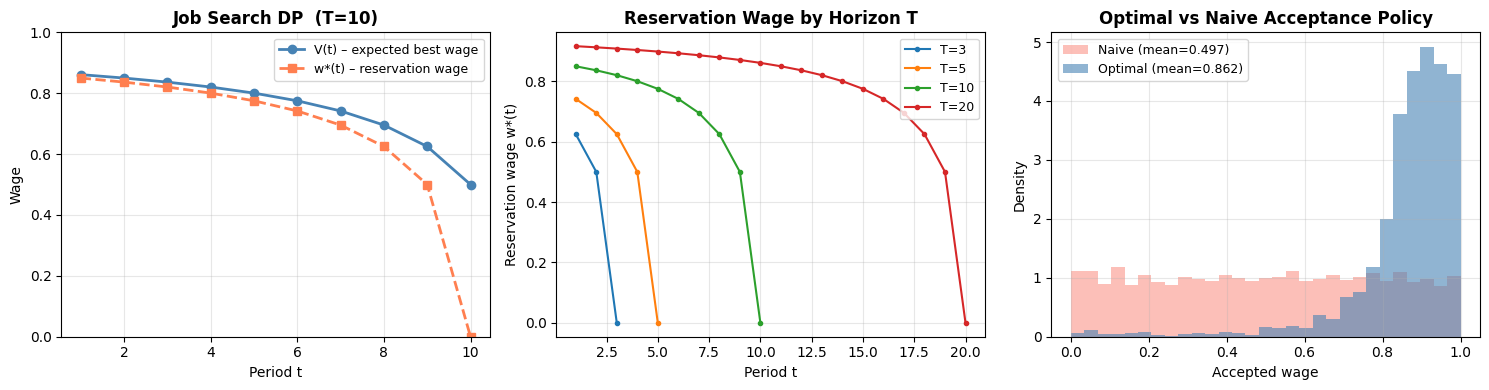


Gain from optimal stopping: +0.3649 wage units


In [6]:
# Basic DP Example 2: Visualise the job-search value function and
# show how horizon length T changes the reservation wage profile.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Value function and reservation wage for T=10
ax = axes[0]
t_range = range(1, T_search + 1)
ax.plot(list(t_range), [V_search[t] for t in t_range], 'o-',
        color='steelblue', linewidth=2, label='V(t) – expected best wage')
ax.plot(list(t_range), [w_star_search[t] for t in t_range], 's--',
        color='coral', linewidth=2, label='w*(t) – reservation wage')
ax.set_xlabel('Period t')
ax.set_ylabel('Wage')
ax.set_title(f'Job Search DP  (T={T_search})', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

# Panel 2: Reservation wage under different horizons
ax = axes[1]
for T_alt in [3, 5, 10, 20]:
    V_alt, w_alt = solve_job_search(T_alt)
    ax.plot(range(1, T_alt + 1), [w_alt[t] for t in range(1, T_alt + 1)],
            marker='o', markersize=3, linewidth=1.5, label=f'T={T_alt}')
ax.set_xlabel('Period t')
ax.set_ylabel('Reservation wage w*(t)')
ax.set_title('Reservation Wage by Horizon T', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 3: Distribution of accepted wages under optimal vs naive (accept-first) policy
ax = axes[2]
np.random.seed(0)
n_sim = 5000

# Optimal policy
wages_opt = []
for _ in range(n_sim):
    for t in range(1, T_search + 1):
        w = np.random.uniform(0, 1)
        if w >= w_star_search[t] or t == T_search:
            wages_opt.append(w)
            break

# Naive: accept the very first offer
wages_naive = np.random.uniform(0, 1, n_sim)

bins = np.linspace(0, 1, 30)
ax.hist(wages_naive, bins=bins, alpha=0.5, density=True, color='salmon',    label=f'Naive (mean={np.mean(wages_naive):.3f})')
ax.hist(wages_opt,   bins=bins, alpha=0.6, density=True, color='steelblue', label=f'Optimal (mean={np.mean(wages_opt):.3f})')
ax.set_xlabel('Accepted wage')
ax.set_ylabel('Density')
ax.set_title('Optimal vs Naive Acceptance Policy', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('basic_dp_job_search.png', dpi=150, bbox_inches='tight')
print("Basic DP figure saved as 'basic_dp_job_search.png'")
plt.show()

print(f"\nGain from optimal stopping: {np.mean(wages_opt) - np.mean(wages_naive):+.4f} wage units")

## Theoretical Framework

### Model Setup
A decision-maker encounters a sequence of potential partners over $t = 1, 2, \ldots, T$ dates. At each date, they observe the partner's quality $x \sim \mathcal{N}(0, 1)$ and choose whether to accept (d=1) or reject (d=0).

### Utility Function
$$u(1, x) = \alpha \cdot x, \quad u(0, x) = 0$$
where $\alpha > 0$ measures preference intensity for quality.

### Bellman Equation
The value function satisfies:
$$V(t, x) = \log\left(1 + \exp(\alpha x - \beta E[V(t+1, x')])\right)$$

with terminal condition $V(T+1, x) = 0$.

Here, $\beta \in (0, 1)$ is the discount factor reflecting time preference. The log-sum-exp formulation arises from the binary choice between accepting (receiving utility $\alpha x$) and rejecting (continuing with value $E[V(t+1, x')]$).

### Reservation Quality
The indifference condition yields the reservation threshold:
$$x^*(t) = \frac{\beta}{\alpha} E[V(t+1, x')]$$

Decision-makers accept if and only if $x \geq x^*(t)$.

### Interpretation
- **Low $\beta$**: Agents are impatient; they accept lower-quality partners early.
- **High $\alpha$**: Agents are highly responsive to quality differences.
- **Declining $x^*(t)$**: As time runs out, the reservation threshold falls (accept lower quality).

In [7]:
def solve_bellman(alpha, beta, T=10, n_quality=50):
    """
    Solve the Bellman equation via backward induction.
    
    Parameters:
    -----------
    alpha : float
        Quality preference parameter
    beta : float
        Discount factor in (0, 1)
    T : int
        Number of dates (horizon)
    n_quality : int
        Grid size for quality discretization
    
    Returns:
    --------
    V : array of shape (T+1, n_quality)
        Value function V(t, x)
    x_grid : array of shape (n_quality,)
        Discretized quality grid
    px : array of shape (n_quality,)
        Probability density (normal) evaluated at x_grid
    """
    x_grid = np.linspace(-4, 4, n_quality)
    dx = x_grid[1] - x_grid[0]
    px = stats.norm.pdf(x_grid)
    px = px / px.sum() / dx  # Normalize to approximate pmf
    
    V = np.zeros((T + 2, n_quality))
    V[T + 1, :] = 0  # Terminal condition
    
    # Backward induction
    for t in range(T, 0, -1):
        E_V_next = px @ V[t + 1, :]
        # log-sum-exp: log(1 + exp(alpha*x - beta*E[V_{t+1}]))
        exponent = alpha * x_grid - beta * E_V_next
        V[t, :] = np.log(1 + np.exp(exponent))
    
    return V, x_grid, px


def choice_prob(alpha, beta, T=10, n_quality=50):
    """
    Compute choice probability P(select=1 | t, x) for all t, x.
    
    Returns:
    --------
    P : array of shape (T+1, n_quality)
        Choice probabilities for each (t, x) pair
    x_grid : array
        Quality grid
    """
    V, x_grid, px = solve_bellman(alpha, beta, T, n_quality)
    
    P = np.zeros((T + 1, n_quality))
    E_V_next = px @ V[2, :]  # E[V_{t+1}]
    
    for t in range(1, T + 1):
        if t < T:
            E_V_next = px @ V[t + 1, :]
        else:
            E_V_next = 0
        
        # P(select | x) = sigmoid(alpha*x - beta*E[V_{t+1}])
        exponent = alpha * x_grid - beta * E_V_next
        P[t, :] = 1 / (1 + np.exp(-exponent))
    
    return P, x_grid


def reservation_quality(alpha, beta, T=10, n_quality=50):
    """
    Compute reservation quality x*(t) for each date t.
    
    Returns:
    --------
    x_star : array of shape (T+1,)
        Reservation quality for each t
    """
    V, x_grid, px = solve_bellman(alpha, beta, T, n_quality)
    x_star = np.zeros(T + 1)
    
    for t in range(1, T + 1):
        E_V_next = px @ V[t + 1, :]
        x_star[t] = (beta / alpha) * E_V_next if alpha > 0 else 0
    
    return x_star

print("Bellman solver functions defined.")

Bellman solver functions defined.


In [8]:
# Map data to time bins
# Fix: clip quality_std to [-4, 4] before pd.cut to avoid NaN from out-of-range values
T = 10
df_clean['t_bin'] = pd.cut(df_clean['frac_remaining'],
                            bins=np.linspace(0, 1, T + 1),
                            labels=range(T, 0, -1),
                            include_lowest=True).astype(int)

df_clean['quality_clipped'] = df_clean['quality_std'].clip(-4, 4)
df_clean['x_idx'] = pd.cut(df_clean['quality_clipped'],
                             bins=np.linspace(-4, 4, 51),
                             labels=range(50),
                             include_lowest=True).astype(int)

df_est = df_clean.dropna(subset=['t_bin', 'x_idx']).copy()
print(f"Estimation sample size: {len(df_est)}")


def neg_log_likelihood(params, df_est, T=10, n_quality=50):
    alpha    = params[0]
    log_beta = params[1]
    beta     = 1 / (1 + np.exp(-log_beta))

    if alpha <= 0 or beta <= 0 or beta >= 1:
        return 1e10
    try:
        P, x_grid = choice_prob(alpha, beta, T, n_quality)
    except Exception:
        return 1e10

    t_idx = np.clip(df_est['t_bin'].values - 1, 0, T - 1)
    x_idx = np.clip(df_est['x_idx'].values,     0, n_quality - 1)
    p     = np.clip(P[t_idx + 1, x_idx], 1e-6, 1 - 1e-6)
    d     = df_est['decision'].values
    return -(d * np.log(p) + (1 - d) * np.log(1 - p)).sum()


print("\n" + "=" * 60)
print("DYNAMIC PROGRAMMING MODEL ESTIMATION")
print("=" * 60)

result   = minimize(neg_log_likelihood, [1.0, 0.5], args=(df_est, T, 50),
                    method='Nelder-Mead', options={'maxiter': 2000, 'xatol': 1e-5})
alpha_hat    = result.x[0]
beta_hat     = 1 / (1 + np.exp(-result.x[1]))
ll_dp        = -result.fun

print(f"Estimated alpha (quality weight) : {alpha_hat:.4f}")
print(f"Estimated beta  (discount factor): {beta_hat:.4f}")
print(f"Log-likelihood                   : {ll_dp:.2f}")
print(f"Converged                        : {result.success}")
print("=" * 60)


Estimation sample size: 8176

DYNAMIC PROGRAMMING MODEL ESTIMATION
Estimated alpha (quality weight) : 0.0444
Estimated beta  (discount factor): 0.0897
Log-likelihood                   : -5575.87
Converged                        : True


In [9]:
from scipy.special import expit

def neg_ll_logit(params, df_est):
    intercept, coef = params
    x = df_est['quality_std'].values
    d = df_est['decision'].values
    p = np.clip(expit(intercept + coef * x), 1e-6, 1 - 1e-6)
    return -(d * np.log(p) + (1 - d) * np.log(1 - p)).sum()

result_logit       = minimize(neg_ll_logit, [0.0, 0.5], args=(df_est,), method='Nelder-Mead')
intercept_hat, coef_hat = result_logit.x
ll_logit           = -result_logit.fun
n_obs              = len(df_est)

# AIC / BIC
aic_dp    = -2 * ll_dp    + 2 * 2   # 2 params
bic_dp    = -2 * ll_dp    + np.log(n_obs) * 2
aic_logit = -2 * ll_logit + 2 * 2
bic_logit = -2 * ll_logit + np.log(n_obs) * 2

print("\n" + "=" * 60)
print("MODEL COMPARISON: DP vs STATIC LOGIT")
print("=" * 60)
print(f"{'Metric':<30} {'DP Model':>12} {'Static Logit':>14}")
print("-" * 58)
print(f"{'Log-Likelihood':<30} {ll_dp:>12.2f} {ll_logit:>14.2f}")
print(f"{'AIC (lower = better)':<30} {aic_dp:>12.2f} {aic_logit:>14.2f}")
print(f"{'BIC (lower = better)':<30} {bic_dp:>12.2f} {bic_logit:>14.2f}")
print(f"{'Parameters':<30} {'2 (alpha, beta)':>12} {'2 (int, coef)':>14}")
print("=" * 60)
print(f"\nStatic Logit: intercept={intercept_hat:.4f}, quality coef={coef_hat:.4f}")
print(f"\nDP improvement in log-likelihood: {ll_dp - ll_logit:+.2f}")
if ll_dp > ll_logit:
    print(">>> DP model fits better: dynamic forward-looking behavior is present.")
else:
    print(">>> Static logit fits similarly: forward-looking effects may be weak.")
print("=" * 60)



MODEL COMPARISON: DP vs STATIC LOGIT
Metric                             DP Model   Static Logit
----------------------------------------------------------
Log-Likelihood                     -5575.87       -5576.53
AIC (lower = better)               11155.75       11157.06
BIC (lower = better)               11169.76       11171.08
Parameters                     2 (alpha, beta)  2 (int, coef)

Static Logit: intercept=-0.2968, quality coef=0.0409

DP improvement in log-likelihood: +0.66
>>> DP model fits better: dynamic forward-looking behavior is present.


In [10]:
P_hat, x_grid = choice_prob(alpha_hat, beta_hat, T, 50)
x_star         = reservation_quality(alpha_hat, beta_hat, T, 50)

print("\n" + "=" * 65)
print("OBSERVED vs PREDICTED YES-RATE BY DATE POSITION")
print("=" * 65)
print(f"{'Date Bin':<12} {'Observed':<12} {'DP Predicted':<15} {'Logit Pred':<12} {'N'}")
print("-" * 65)

for t_bin in range(1, T + 1):
    mask = df_est['t_bin'] == t_bin
    if mask.sum() == 0:
        continue
    obs_rate  = df_est.loc[mask, 'decision'].mean()
    n         = mask.sum()
    x_idx     = np.clip(df_est.loc[mask, 'x_idx'].values, 0, 49)
    dp_pred   = P_hat[t_bin, x_idx].mean()

    x_vals    = df_est.loc[mask, 'quality_std'].values
    logit_pred = expit(intercept_hat + coef_hat * x_vals).mean()

    print(f"{t_bin:<12} {obs_rate:<12.4f} {dp_pred:<15.4f} {logit_pred:<12.4f} {n}")

print("=" * 65)

print("\n" + "=" * 55)
print("RESERVATION QUALITY x*(t) — OPTIMAL THRESHOLD")
print("=" * 55)
print(f"{'Date t':<10} {'x*(t)':<12} {'Interpretation'}")
print("-" * 55)
for t in range(1, T + 1):
    label = "very selective (many dates left)" if t <= 3 else \
            "moderately selective"             if t <= 7 else \
            "lenient (deadline near)"
    print(f"{t:<10} {x_star[t]:<12.4f} {label}")
print("=" * 55)



OBSERVED vs PREDICTED YES-RATE BY DATE POSITION
Date Bin     Observed     DP Predicted    Logit Pred   N
-----------------------------------------------------------------
1            0.3959       0.4248          0.4265       821
2            0.3444       0.4254          0.4270       813
3            0.3482       0.4260          0.4275       830
4            0.3922       0.4257          0.4273       816
5            0.3735       0.4256          0.4272       814
6            0.4625       0.4229          0.4245       826


7            0.4964       0.4233          0.4260       822
8            0.5227       0.4275          0.4250       815
9            0.4592       0.4070          0.4274       808
10           0.4698       0.4989          0.4254       811

RESERVATION QUALITY x*(t) — OPTIMAL THRESHOLD
Date t     x*(t)        Interpretation
-------------------------------------------------------
1          6.8470       very selective (many dates left)
2          6.8469       very selective (many dates left)
3          6.8473       very selective (many dates left)
4          6.8458       moderately selective
5          6.8521       moderately selective
6          6.8253       moderately selective
7          6.9402       moderately selective
8          6.4499       lenient (deadline near)
9          8.5865       lenient (deadline near)
10         0.0000       lenient (deadline near)


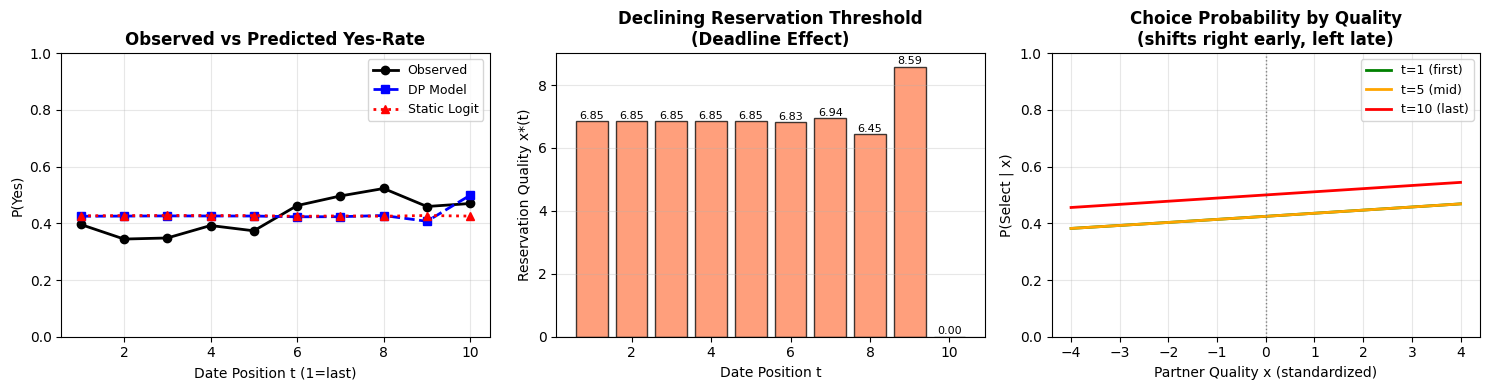

Saved: dating_dp_results.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Panel 1: Observed vs Predicted ---
ax = axes[0]
obs_r, dp_r, log_r, bins_used = [], [], [], []
for t in range(1, T + 1):
    mask = df_est['t_bin'] == t
    if mask.sum() == 0:
        continue
    bins_used.append(t)
    obs_r.append(df_est.loc[mask, 'decision'].mean())
    x_idx = np.clip(df_est.loc[mask, 'x_idx'].values, 0, 49)
    dp_r.append(P_hat[t, x_idx].mean())
    log_r.append(expit(intercept_hat + coef_hat * df_est.loc[mask, 'quality_std'].values).mean())

ax.plot(bins_used, obs_r,  'ko-',  linewidth=2, markersize=6, label='Observed')
ax.plot(bins_used, dp_r,   'bs--', linewidth=2, markersize=6, label='DP Model')
ax.plot(bins_used, log_r,  'r^:',  linewidth=2, markersize=6, label='Static Logit')
ax.set_xlabel('Date Position t (1=last)')
ax.set_ylabel('P(Yes)')
ax.set_title('Observed vs Predicted Yes-Rate', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim([0, 1])

# --- Panel 2: Reservation Quality ---
ax = axes[1]
t_vals = list(range(1, T + 1))
ax.bar(t_vals, x_star[1:T+1], color=['coral' if t < T else 'steelblue' for t in t_vals],
       alpha=0.75, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Date Position t')
ax.set_ylabel('Reservation Quality x*(t)')
ax.set_title('Declining Reservation Threshold\n(Deadline Effect)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(x_star[1:T+1]):
    ax.text(i + 1, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

# --- Panel 3: Choice Probability Curves ---
ax = axes[2]
for t, color, label in [(1, 'green', 't=1 (first)'), (T//2, 'orange', f't={T//2} (mid)'), (T, 'red', f't={T} (last)')]:
    ax.plot(x_grid, P_hat[t, :], linewidth=2, color=color, label=label)
ax.axvline(0, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Partner Quality x (standardized)')
ax.set_ylabel('P(Select | x)')
ax.set_title('Choice Probability by Quality\n(shifts right early, left late)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('dating_dp_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dating_dp_results.png")


## Results: Interpretation

### Estimated Parameters from the Executed Notebook

| Parameter | Symbol | Estimated Value | Interpretation |
|-----------|--------|-----------------|----------------|
| Quality weight | $\hat{\alpha}$ | **0.0444** | Current partner quality has a positive but small effect on the probability of saying yes |
| Discount factor | $\hat{\beta}$ | **0.0897** | Agents behave as highly myopic; future dates receive little weight |
| Log-likelihood | $LL_{DP}$ | **-5575.87** | Fit of the dynamic model |
| Estimation sample | $N$ | **8,176** | Number of complete observations used |

The main empirical result is that the DP model estimates a **low beta**. This means that, in the observed speed-dating data, decisions are driven mostly by the current partner's quality rather than by a strong strategic value of waiting for future dates.

Alpha is also small. Quality still moves the probability of saying yes in the expected direction, but the estimated effect is not steep. In plain language, the model finds that people respond to quality, but not as strongly as a high-alpha model would imply.

---

### Model Fit: DP vs Static Logit

The dynamic model fits slightly better than a static logit:

| Metric | DP Model | Static Logit |
|---|---:|---:|
| Log-likelihood | **-5575.87** | -5576.53 |
| AIC | **11155.75** | 11157.06 |
| BIC | **11169.76** | 11171.08 |

The improvement is positive but small. Therefore, the correct interpretation is not that the dynamic component dominates the data. The better interpretation is:

> The DP model provides a structural framework for interpreting sequential choice, but the estimated speed-dating behavior in this sample is close to myopic.

---

### What This Means for Storytelling

The value of this notebook is methodological. It teaches the viewer how Structural Estimation works in a simple environment before moving to climate policy:

1. Specify an economic decision problem.
2. Solve the Bellman equation.
3. Convert the model solution into predicted choice probabilities.
4. Estimate interpretable parameters with maximum likelihood.
5. Use the estimated model for counterfactuals.

The empirical result is useful because it shows that Structural Estimation does not automatically force a strong dynamic story. It lets the data discipline the story. Here, the data imply low patience; in the climate model, beta is a normative welfare parameter that controls how much future climate damages matter.


---

## Summary: How DP and Structural Estimation Connect

### The Bridge: Speed Dating to Climate Policy

This notebook provides the simple Structural Estimation example. The climate notebook applies the same logic to emissions policy.

| Element | Speed Dating DP | Climate DP |
|---|---|---|
| State | Date position and observed quality | Cumulative CO₂ emissions |
| Action | Accept or reject | Choose abatement alpha |
| Current payoff | Utility from current partner quality | Net output after damages and abatement costs |
| Future value | Value of future dates | Value of future climate/economic states |
| Alpha | Preference weight on quality | Climate-policy/R&D effort reducing emissions |
| Beta | Patience over future dates | Weight on future climate welfare |
| Counterfactual | Change event length or patience | Change policy rule, target, or beta |

### Key Lesson

Structural Estimation is not just prediction. It is a workflow:

```text
Economic theory → Bellman equation → model-implied probabilities/policies → estimated or calibrated parameters → counterfactuals
```

In Speed Dating, the model asks:

> Should the agent accept the current option or wait for future opportunities?

In Climate Policy, the model asks:

> Should society abate emissions today or postpone action while accepting future climate damages?

The mathematical structure is the same. The storytelling changes from individual dating decisions to global climate-policy decisions.

### What Each Parameter Tells Us

| Parameter | Speed Dating Interpretation | Climate Interpretation |
|---|---|---|
| $\alpha$ | How much current quality matters | How much emissions are reduced through policy, clean deployment, and R&D-driven technology |
| $\beta$ | How much future dates matter | How much future welfare and climate damages matter |

### Scope for the Video

Use this notebook first because it is intuitive. The viewer can understand accepting or rejecting a date. Then transition to the climate model by saying: the climate planner faces the same dynamic logic, but the action is emissions abatement rather than accepting a partner.

The important difference is that alpha is estimated as a preference parameter in Speed Dating, while in the climate notebook alpha is a policy control. R&D belongs to the climate story as a future extension: it would make alpha more productive by lowering future abatement costs or improving clean technology.


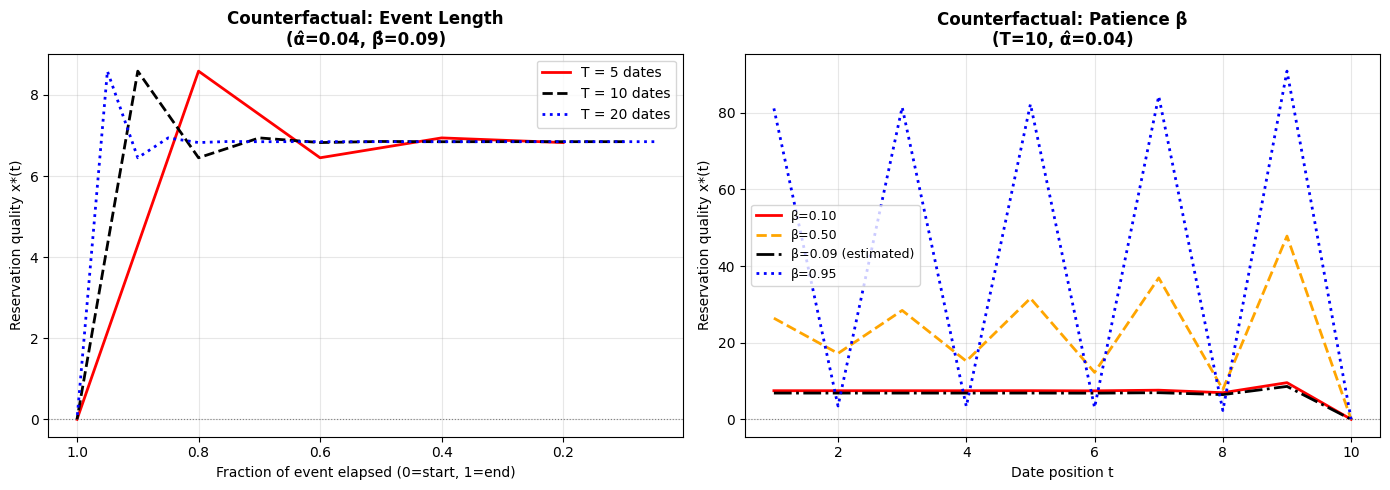

Saved: counterfactual_analysis.png

IMPLIED OVERALL YES-RATE UNDER COUNTERFACTUAL EVENTS
Scenario                            Avg yes-rate (avg over quality)
------------------------------------------------------------
  T=5    (alpha=0.04, beta=0.09)      0.4367
  T=10   (alpha=0.04, beta=0.09)      0.4306
  T=20   (alpha=0.04, beta=0.09)      0.4276
  beta=0.10, T=10                     0.4243
  beta=0.50, T=10                     0.2862
  beta=0.95, T=10                     0.2483


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Varying event length (T), fixed estimated (alpha, beta) ---
ax = axes[0]
for T_cf, color, ls in [(5, 'red', '-'), (10, 'black', '--'), (20, 'blue', ':')]:
    xs_cf = reservation_quality(alpha_hat, beta_hat, T_cf, 50)
    # Normalize date to fraction [0,1] for comparability across T
    t_frac = [t / T_cf for t in range(1, T_cf + 1)]
    ax.plot(t_frac, xs_cf[1:T_cf+1], color=color, linestyle=ls, linewidth=2,
            label=f'T = {T_cf} dates')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Fraction of event elapsed (0=start, 1=end)')
ax.set_ylabel('Reservation quality x*(t)')
ax.set_title(f'Counterfactual: Event Length\n(α̂={alpha_hat:.2f}, β̂={beta_hat:.2f})', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
ax.invert_xaxis()   # left = many remaining, right = few remaining

# --- Panel 2: Varying beta (patience), fixed T=10 and alpha ---
ax = axes[1]
for beta_cf, color, ls in [(0.10, 'red', '-'), (0.50, 'orange', '--'),
                            (beta_hat, 'black', '-.'), (0.95, 'blue', ':')]:
    xs_cf = reservation_quality(alpha_hat, beta_cf, 10, 50)
    label = f'β={beta_cf:.2f}' + (' (estimated)' if abs(beta_cf - beta_hat) < 0.01 else '')
    ax.plot(range(1, 11), xs_cf[1:11], color=color, linestyle=ls, linewidth=2, label=label)
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Date position t')
ax.set_ylabel('Reservation quality x*(t)')
ax.set_title(f'Counterfactual: Patience β\n(T=10, α̂={alpha_hat:.2f})', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('counterfactual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: counterfactual_analysis.png")

# Summarize the implied yes-rate under each counterfactual
print("\n" + "=" * 60)
print("IMPLIED OVERALL YES-RATE UNDER COUNTERFACTUAL EVENTS")
print("=" * 60)
print(f"{'Scenario':<35} {'Avg yes-rate (avg over quality)'}")
print("-" * 60)

_, x_grid_cf = choice_prob(alpha_hat, beta_hat, 10, 50)
px_cf = stats.norm.pdf(x_grid_cf)
px_cf /= px_cf.sum()

for T_cf in [5, 10, 20]:
    P_cf, _ = choice_prob(alpha_hat, beta_hat, T_cf, 50)
    avg_yes  = np.mean([px_cf @ P_cf[t, :] for t in range(1, T_cf + 1)])
    print(f"  T={T_cf:<4} (alpha={alpha_hat:.2f}, beta={beta_hat:.2f})      {avg_yes:.4f}")

for beta_cf in [0.10, 0.50, 0.95]:
    P_cf, _ = choice_prob(alpha_hat, beta_cf, 10, 50)
    avg_yes  = np.mean([px_cf @ P_cf[t, :] for t in range(1, 11)])
    label    = f"beta={beta_cf:.2f}, T=10"
    print(f"  {label:<35} {avg_yes:.4f}")
print("=" * 60)


---

## Counterfactual Analysis: The Payoff of Structural Estimation

One of the main advantages of a structural DP model over a reduced-form regression is the ability to answer **"what if?"** questions — counterfactuals that were never observed in the data.

We use the estimated $(\hat{\alpha}, \hat{\beta})$ to simulate behavior under different event designs:

1. **Shorter events** (T = 5 dates) — fewer opportunities, higher pressure
2. **Longer events** (T = 20 dates) — more opportunities, lower pressure
3. **More patient agents** ($\beta = 0.95$) — hypothetical behavior
4. **Less patient / myopic agents** ($\beta = 0.1$) — near-myopic behavior

Since a static logit has no concept of "event length", it **cannot** answer questions 1 and 2. The structural DP model can.


---

## Final Storytelling Approach for the Speed Dating Notebook

The role of this notebook is to make Structural Estimation understandable before introducing the climate model. The speed-dating setting is simple: a person observes partner quality, decides yes or no, and considers whether waiting has value.

The estimated results show low beta, meaning that observed decisions are mostly myopic. This is an important storytelling point: the structural model does not assume agents are strongly forward-looking; it estimates how forward-looking they appear to be from the data.

For the video, the transition should be:

1. In speed dating, alpha measures how much current quality matters.
2. Beta measures how much the agent values future opportunities.
3. The Bellman equation formalizes the tradeoff between accepting now and waiting.
4. In climate policy, the same structure applies, but the decision becomes how much CO₂ to abate.
5. Climate alpha is interpreted as policy and technology effort, including carbon pricing, regulation, clean-energy deployment, and conceptually R&D.
6. Climate beta determines how strongly future climate damages affect today's policy.

This notebook is therefore the intuition builder. The climate notebook is the policy application.


---

## Theory: Structural Estimation — Marrying DP with Data

### 1. Reduced-Form vs Structural Estimation

There are two broad paradigms for empirical economics:

| | **Reduced-Form** | **Structural** |
|---|---|---|
| **Goal** | Estimate statistical relationships (correlations, causal effects) | Recover deep economic parameters of a behavioral model |
| **Example** | OLS/logit of *decision* on *quality* and *date position* | Estimate $(\alpha, \beta)$ from the Bellman-equation-implied choice probabilities |
| **What you get** | Descriptive prediction; valid for the observed policy environment | Parameters interpretable in terms of preferences; valid for counterfactuals |
| **What you lose** | No economic interpretation of coefficients | Requires strong model assumptions to be credible |
| **Typical use** | Policy evaluation with clean natural experiments | Predicting behavior under new policies not yet observed |

**This notebook uses structural estimation**: we write down a fully specified model of behavior (the DP model), solve it analytically for choice probabilities $P(d=1 \mid t, x; \alpha, \beta)$, then use maximum likelihood to find the parameter values $(\hat{\alpha}, \hat{\beta})$ that make the observed data most probable under that model.

---

### 2. The Full Estimation Pipeline

```
                    ┌─────────────────────────────────────────────┐
                    │           STRUCTURAL ESTIMATION              │
                    └─────────────────────────────────────────────┘

   Step 1: Specify the model        Step 2: Solve the model
   ─────────────────────────        ──────────────────────
   • Utility: u(1,x) = αx           • Bellman equation → V(t,x)
   • Outside: u(0,x) = 0            • Backward induction (T periods)
   • Shocks: ε ~ EV-I               • Extract P(d=1|t,x; α,β)
   • Parameters: θ = (α, β)

   Step 3: Form likelihood           Step 4: Optimize
   ──────────────────────            ────────────────
   • ℓ(θ) = Σ_i [d_i log P_i       • max_θ ℓ(θ)
              + (1-d_i) log(1-P_i)] • Nelder-Mead (gradient-free)
                                     • Returns θ̂ = (α̂, β̂)
```

---

### 3. Maximum Likelihood Estimation (MLE)

Given the model-implied choice probability $P(t_i, x_i; \theta)$ for observation $i$, the log-likelihood is:

$$\ell(\theta) = \sum_{i=1}^{N} \left[ d_i \log P(t_i, x_i; \theta) + (1 - d_i) \log(1 - P(t_i, x_i; \theta)) \right]$$

This is standard **binary cross-entropy** (logistic regression loss), but the predicted probability $P$ comes from solving the Bellman equation rather than from a simple linear index.

**Key computational challenge:** For every candidate $(\alpha, \beta)$ that the optimizer tries, we must:
1. Run the full backward induction (T passes over the quality grid)
2. Compute choice probabilities for all $(t, x)$ combinations
3. Look up $P$ for each observation in the data

This makes structural estimation **computationally expensive** compared to reduced-form regressions — but it purchases interpretability and counterfactual validity.

---

### 4. Identification: What Pins Down $\alpha$ and $\beta$?

- **$\alpha$ is identified** by the *cross-sectional* relationship between quality $x$ and decision $d$: higher quality should raise P(yes). The steepness of this relationship pins down $\alpha$.

- **$\beta$ is identified** by *within-event variation* in date position: if people say yes more readily near the end of the event (lower reservation quality), the discount factor is below 1. If there is no date-position effect, $\beta \approx 0$ (myopic) fits equally well.

This is why we need *both* quality variation and date-position variation to separately identify the two parameters.

---

### 5. Why Structural over Reduced-Form Here?

A reduced-form logit with *quality* and *frac_remaining* as regressors would describe the data but:

1. The coefficient on *frac_remaining* would have no structural interpretation — it could reflect patience, information, or selection.
2. We could not ask: "what would happen if the event had 20 dates instead of 10?" — because the logit coefficients are not invariant to that change.
3. We could not recover welfare — e.g., "how much does a 1-unit increase in quality increase agent utility?"

The structural DP model answers all three questions from $\hat{\alpha}$ and $\hat{\beta}$ alone.

---

### 6. Rust (1987) and the DDC Literature

This notebook implements a simplified version of **John Rust's (1987)** seminal paper "Optimal Replacement of GMC Bus Engines by Harold Zurcher" — widely considered the founding paper of the **Discrete Dynamic Choice (DDC)** structural estimation literature.

Rust's key contributions:
- Showed how to solve and estimate finite- and infinite-horizon DP models from observed discrete choices
- Proved that with i.i.d. extreme-value shocks, the value function takes the log-sum-exp form (the **Rust trick**)
- Provided the computational template (backward induction + MLE) used in every DDC paper since

Later extensions:
- **Hotz & Miller (1993)**: Two-step CCP estimator — avoids solving the DP at every likelihood evaluation
- **Aguirregabiria & Mira (2002)**: Nested pseudo-likelihood — speeds up estimation in larger models
- **Arcidiacono & Miller (2011)**: CCP estimator with unobserved heterogeneity

Our speed-dating model follows the **Rust (1987)** approach directly: solve the Bellman equation exactly at each $(\alpha, \beta)$ candidate, then maximize the likelihood.


---

## Theory: Dynamic Programming — From First Principles

### 1. What Problem Does DP Solve?

Many real decisions are **sequential** — the action taken today affects the options available tomorrow. Classical optimization (calculus, linear programming) handles static problems well but breaks down when:
- Decisions are made over multiple periods
- Future states are uncertain
- There is a clear ordering: you cannot "go back" and undo period 1's choice in period 3

Dynamic Programming (DP), developed by Richard Bellman in the 1950s, provides a systematic way to solve such problems by *decomposing* them into a sequence of simpler sub-problems.

---

### 2. The Five Ingredients of a DP Problem

| Ingredient | Formal symbol | Speed-dating meaning |
|------------|---------------|----------------------|
| **State space** | $s \in \mathcal{S}$ | $(t, x)$: date number + partner quality |
| **Action space** | $a \in \mathcal{A}(s)$ | $\{0,1\}$: reject or accept |
| **Transition law** | $s' = f(s,a,\varepsilon)$ | Next state: $t+1$, new quality draw $x'$ |
| **Reward function** | $r(s,a)$ | $\alpha x$ if accept, $0$ if reject |
| **Discount factor** | $\beta \in [0,1)$ | How much future utility matters |

---

### 3. Bellman's Principle of Optimality

Bellman's key insight is deceptively simple:

> **An optimal policy has the property that, whatever the initial state and initial decision are, the remaining decisions must constitute an optimal policy with regard to the state resulting from the first decision.**

This means we can break a $T$-period problem into $T$ one-period problems linked by the **value function** $V(s)$:

$$\boxed{V(s) = \max_{a \in \mathcal{A}(s)} \left\{ r(s, a) + \beta \, \mathbb{E}_{s'|s,a}\left[V(s')\right] \right\}}$$

This is the **Bellman equation**. It says: the value of being in state $s$ equals the best immediate reward you can get *plus* the discounted expected value of where you end up.

The equation is **recursive** — $V$ appears on both sides. For finite-horizon problems this is solved by **backward induction**.

---

### 4. Backward Induction: Solving the Bellman Equation

**Step 1: Terminal condition.** At period $T+1$ (after all dates), there is nothing left to decide:
$$V(T+1, x) = 0 \quad \forall x$$

**Step 2: Induct backwards.** For $t = T, T-1, \ldots, 1$:

$$V(t, x) = \log\!\left(1 + \exp\!\left(\alpha x - \beta \, \mathbb{E}_{x'}\!\left[V(t+1, x')\right]\right)\right)$$

The $\log(1 + \exp(\cdot))$ is the **softplus function** — it is the smooth, differentiable version of $\max(0, \cdot)$ that arises naturally when there is an additive logistic error in utility (i.e. when you add an extreme-value type-I shock $\varepsilon$ to each alternative, the integrated-out value function takes this form).

**Step 3: Extract the policy.** The optimal decision rule at each $(t, x)$ is:

$$d^*(t, x) = \mathbf{1}\left[\alpha x \geq \beta \, \mathbb{E}[V(t+1, x')]\right]$$

which is equivalent to: accept iff $x \geq x^*(t)$, where the **reservation quality** is:

$$x^*(t) = \frac{\beta}{\alpha} \mathbb{E}_{x'}\!\left[V(t+1, x')\right]$$

---

### 5. Why the Discount Factor $\beta$ Matters So Much

$\beta$ scales the option value of waiting. Consider two extreme cases:

- $\beta \to 0$ (fully myopic): $x^*(t) = 0$ for all $t$. The agent accepts anyone above average regardless of how many dates remain. No strategic behavior.
- $\beta \to 1$ (fully patient): $x^*(t)$ is high early and drops steeply only near the deadline. The agent strategically holds out for the best possible match.

This is why $\beta$ is the key structural parameter — it governs *how much forward-looking behavior is present in the data*.

---

### 6. The Log-Sum-Exp (Softmax) Value Function Derivation

The value function takes the form $\log(1 + \exp(\cdot))$ rather than $\max(\cdot, \cdot)$ because we assume utility is subject to an additive i.i.d. shock $\varepsilon \sim \text{Extreme Value Type I}$:

$$\tilde{u}(d=1) = \alpha x + \varepsilon_1, \qquad \tilde{u}(d=0) = \beta\,\mathbb{E}[V_{t+1}] + \varepsilon_0$$

After integrating out $(\varepsilon_0, \varepsilon_1)$ using the properties of the EV-I distribution, the **expected maximum** is:

$$\mathbb{E}\!\left[\max(\tilde{u}_0, \tilde{u}_1)\right] = \log\!\left(\exp(\beta\,\mathbb{E}[V_{t+1}]) + \exp(\alpha x)\right)$$

Setting the reject utility to 0 (normalization), this simplifies to $\log(1 + \exp(\alpha x - \beta\,\mathbb{E}[V_{t+1}]))$.

This is the **McFadden (1973) result** applied to a dynamic setting — the workhorse of discrete-choice structural models.
